In [ ]:
!pip install tensorflow scikit-learn joblib matplotlib pandas numpy

In [ ]:
from google.colab import files
files.upload()

In [ ]:
import zipfile
with zipfile.ZipFile("PD_Dataset.zip", "r") as zip_ref:
    zip_ref.extractall(".")
print("Dataset extracted successfully!")

In [ ]:
import os
print(os.listdir("PD_Dataset"))

In [ ]:
import os

print(os.listdir())

In [ ]:
import os
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from IPython.display import display, Image as IPImage
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    matthews_corrcoef
)

In [ ]:
# Configuration
SEED = 42

VOICE_CSV = "parkinsons.csv"
ZIP_PATH = "PD_Dataset.zip"
IMAGE_ROOT = "PD_Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS_CNN = 6

VOICE_TEST_SIZE = 0.2
VOICE_VAL_SPLIT = 0.2

OUTPUT_DIR = "outputs"
MODEL_DIR = "models"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
# utility functions for plots + metrics
def metrics_summary(y_true, y_pred, y_prob=None):
    rec = {}
    rec['accuracy'] = float(accuracy_score(y_true, y_pred))
    rec['precision'] = float(precision_score(y_true, y_pred, zero_division=0))
    rec['recall'] = float(recall_score(y_true, y_pred, zero_division=0))
    rec['f1'] = float(f1_score(y_true, y_pred, zero_division=0))
    try:
        rec['mcc'] = float(matthews_corrcoef(y_true, y_pred))
    except:
        rec['mcc'] = float('nan')
    if y_prob is not None:
        try:
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            rec['auc'] = float(auc(fpr, tpr))
        except:
            rec['auc'] = float('nan')
    else:
        rec['auc'] = float('nan')
    return rec

def save_confusion_matrix(y_true, y_pred, title, fname):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for (i,j), val in np.ndenumerate(cm):
        ax.text(j, i, int(val), ha='center', va='center', color='black')
    plt.tight_layout()
    out = f'{OUTPUT_DIR}/{fname}_conf.png'; fig.savefig(out); plt.close(fig)
    return out

def save_roc_curve(y_true, y_prob, title, fname):
    if y_prob is None: return None
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr,tpr)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}')
    plt.plot([0,1],[0,1],'--',alpha=0.4)
    plt.title(title + ' — ROC'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(loc='lower right')
    out = f'{OUTPUT_DIR}/{fname}_roc.png'; plt.tight_layout(); plt.savefig(out); plt.close()
    return out

def save_pr_curve(y_true, y_prob, title, fname):
    if y_prob is None: return None
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    aupr = auc(rec, prec)
    plt.figure(figsize=(5,4))
    plt.plot(rec, prec, label=f'AUPR={aupr:.3f}')
    plt.title(title + ' — PR'); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend(loc='lower left')
    out = f'{OUTPUT_DIR}/{fname}_pr.png'; plt.tight_layout(); plt.savefig(out); plt.close()
    return out

def display_table(df, title=None):
    if title: print(title)
    print(df.to_markdown(index=False, floatfmt=".4f"))


In [ ]:
# ----------------- Prepare image dataset (unzip if needed) -----------------
if not os.path.exists(IMAGE_ROOT):
    if os.path.exists(ZIP_PATH):
        print(f'Found {ZIP_PATH} — extracting to working directory...')
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall('.')
        if not os.path.exists(IMAGE_ROOT):
            raise FileNotFoundError(f"After extracting {ZIP_PATH}, expected folder {IMAGE_ROOT} not found.")
        print('Extraction completed.')
    else:
        print(f'Image folder "{IMAGE_ROOT}" not found and {ZIP_PATH} not found. Image pipeline will be skipped.')


In [51]:
# ----------------- VOICE pipeline -----------------
voice_results_df = None
voice_best_clf = None
voice_info = None

if os.path.exists(VOICE_CSV):
    print('\n=== VOICE TRAINING ===')
    df = pd.read_csv(VOICE_CSV)
    print('Loaded CSV shape:', df.shape)
    # normalize label column name to 'status'
    if 'status' not in df.columns:
        for alt in ['status','label','target','diagnosis','class','status_group']:
            if alt in df.columns:
                df = df.rename(columns={alt:'status'}); break
    if 'status' not in df.columns:
        raise ValueError("CSV must contain a label column. Rename it to 'status' (0 healthy, 1 Parkinson).")
    # keep numeric columns only (prevents string -> float errors)
    numeric = df.select_dtypes(include=[np.number]).copy()
    if 'status' not in numeric.columns:
        # attempt to coerce status
        numeric['status'] = pd.to_numeric(df['status'], errors='coerce')
    X = numeric.drop(columns=['status'])
    y = numeric['status'].astype(int)
    print('Using numeric features:', X.shape[1])
    if X.isna().any().any():
        X = X.fillna(X.mean())
    scaler = StandardScaler().fit(X)
    joblib.dump(scaler, f'{MODEL_DIR}/voice_scaler.joblib')
    Xs = scaler.transform(X)
    X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=VOICE_TEST_SIZE, stratify=y, random_state=SEED)
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=VOICE_VAL_SPLIT, stratify=y_train, random_state=SEED)
    print('Train/Val/Test shapes:', X_tr.shape, X_val.shape, X_test.shape)

    # classifiers (no stacking)
    classifiers = {}
    # SVM -> tune and calibrate
    svc = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=SEED)
    svc_cv = GridSearchCV(svc, {'C':[1,5]}, scoring='f1', cv=3, n_jobs=-1)
    svc_cv.fit(X_tr, y_tr)
    svc_best = svc_cv.best_estimator_
    svc_cal = CalibratedClassifierCV(svc_best, cv='prefit'); svc_cal.fit(X_tr, y_tr)
    classifiers['SVM'] = svc_cal
    joblib.dump(svc_cal, f'{MODEL_DIR}/voice_SVM.joblib')

    # kNN
    knn = KNeighborsClassifier()
    knn_cv = GridSearchCV(knn, {'n_neighbors':[3,5,7]}, scoring='f1', cv=3, n_jobs=-1)
    knn_cv.fit(X_tr, y_tr)
    knn_best = knn_cv.best_estimator_
    knn_cal = CalibratedClassifierCV(knn_best, cv='prefit'); knn_cal.fit(X_tr, y_tr)
    classifiers['kNN'] = knn_cal
    joblib.dump(knn_cal, f'{MODEL_DIR}/voice_kNN.joblib')

    # Logistic
    log = LogisticRegression(max_iter=600, class_weight='balanced', solver='liblinear', random_state=SEED)
    log_cv = GridSearchCV(log, {'C':[0.5,1,5]}, scoring='f1', cv=3, n_jobs=-1)
    log_cv.fit(X_tr, y_tr)
    log_best = log_cv.best_estimator_
    log_cal = CalibratedClassifierCV(log_best, cv='prefit'); log_cal.fit(X_tr, y_tr)
    classifiers['Logistic'] = log_cal
    joblib.dump(log_cal, f'{MODEL_DIR}/voice_Logistic.joblib')

    # MLP
    mlp = MLPClassifier(max_iter=800, random_state=SEED)
    mlp_cv = GridSearchCV(mlp, {'hidden_layer_sizes':[(50,),(100,)], 'alpha':[1e-4,1e-3]}, scoring='f1', cv=3, n_jobs=-1)
    mlp_cv.fit(X_tr, y_tr)
    mlp_best = mlp_cv.best_estimator_
    mlp_cal = CalibratedClassifierCV(mlp_best, cv='prefit'); mlp_cal.fit(X_tr, y_tr)
    classifiers['MLP'] = mlp_cal
    joblib.dump(mlp_cal, f'{MODEL_DIR}/voice_MLP.joblib')

    # Evaluate and save metrics + plots
    voice_records = []
    for name, clf in classifiers.items():
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1] if hasattr(clf,'predict_proba') else None
        rec = metrics_summary(y_test, y_pred, y_prob)
        rec['model'] = name
        voice_records.append(rec)
        conf_png = save_confusion_matrix(y_test, y_pred, f'Voice {name} (test)', f'voice_{name}')
        roc_png = save_roc_curve(y_test, y_prob, f'Voice {name} (test)', f'voice_{name}')
        pr_png = save_pr_curve(y_test, y_prob, f'Voice {name} (test)', f'voice_{name}')

    voice_results_df = pd.DataFrame(voice_records).sort_values('f1', ascending=False).reset_index(drop=True)
    voice_results_df.to_csv(f'{OUTPUT_DIR}/voice_test_metrics.csv', index=False)
    print('\nVoice results table:')
    display_table(voice_results_df, title='Voice test metrics (sorted by F1)')

    best_voice_name = voice_results_df.loc[0,'model']
    voice_best_clf = classifiers[best_voice_name]
    joblib.dump(voice_best_clf, f'{MODEL_DIR}/voice_best.joblib')
    print('\nBEST VOICE MODEL (by test F1):', best_voice_name)

    # Save best confusion + roc; show random-correct samples (search)
    y_pred_best = voice_best_clf.predict(X_test)
    y_prob_best = voice_best_clf.predict_proba(X_test)[:,1] if hasattr(voice_best_clf,'predict_proba') else None
    save_confusion_matrix(y_test, y_pred_best, f'Voice {best_voice_name} (BEST)', f'voice_best_{best_voice_name}')
    save_roc_curve(y_test, y_prob_best, f'Voice {best_voice_name} (BEST)', f'voice_best_{best_voice_name}')
    # Find random correct samples per class
    attempts=1000; need_per_class=2
    found={'0':[],'1':[]}
    for _ in range(attempts):
        idx = random.randrange(0, X_test.shape[0])
        x = X_test[idx:idx+1]
        actual = int(y_test.iloc[idx]) if isinstance(y_test, pd.Series) else int(y_test[idx])
        pred = int(voice_best_clf.predict(x)[0])
        prob = float(voice_best_clf.predict_proba(x)[0,1]) if hasattr(voice_best_clf,'predict_proba') else None
        if pred==actual and len(found[str(actual)])<need_per_class:
            found[str(actual)].append((idx, actual, pred, prob))
        if len(found['0'])>=need_per_class and len(found['1'])>=need_per_class:
            break
    print('\nRandom correctly-predicted voice samples (idx, actual, pred, prob):')
    for lab in ['0','1']:
        print(f'Class {lab}:', found[lab] if found[lab] else 'None found')

else:
    print(f'\nVoice CSV {VOICE_CSV} not found. Skipping voice pipeline.')


=== VOICE TRAINING ===
Loaded CSV shape: (195, 24)
Using numeric features: 22
Train/Val/Test shapes: (124, 22) (32, 22) (39, 22)


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



Voice results table:
Voice test metrics (sorted by F1)
|   accuracy |   precision |   recall |     f1 |    mcc |    auc | model    |
|-----------:|------------:|---------:|-------:|-------:|-------:|:---------|
|     0.9487 |      0.9655 |   0.9655 | 0.9655 | 0.8655 | 0.9862 | MLP      |
|     0.9231 |      0.9333 |   0.9655 | 0.9492 | 0.7934 | 0.9569 | kNN      |
|     0.8974 |      0.9310 |   0.9310 | 0.9310 | 0.7310 | 0.9379 | SVM      |
|     0.8718 |      0.9286 |   0.8966 | 0.9123 | 0.6759 | 0.9448 | Logistic |

BEST VOICE MODEL (by test F1): MLP

Random correctly-predicted voice samples (idx, actual, pred, prob):
Class 0: [(19, 0, 0, 0.024381880051165865), (19, 0, 0, 0.024381880051165865)]
Class 1: [(17, 1, 1, 0.9906416178923726), (2, 1, 1, 0.9905896144353058)]



=== IMAGE PIPELINE ===

--- Modality: spiral ---
Found 72 files belonging to 2 classes.
Found 30 files belonging to 2 classes.
Classes: ['healthy', 'parkinson']
Epoch 1/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 884ms/step - accuracy: 0.4028 - loss: 0.7753 - val_accuracy: 0.6667 - val_loss: 0.6329
Epoch 2/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 473ms/step - accuracy: 0.6667 - loss: 0.6666 - val_accuracy: 0.6667 - val_loss: 0.5804
Epoch 3/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 683ms/step - accuracy: 0.7083 - loss: 0.5932 - val_accuracy: 0.6333 - val_loss: 0.5515
Epoch 4/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 464ms/step - accuracy: 0.6389 - loss: 0.6342 - val_accuracy: 0.6667 - val_loss: 0.5230
Epoch 5/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 503ms/step - accuracy: 0.6806 - loss: 0.5938 - val_accuracy: 0.7000 - val_loss: 0.4970
Epoch 6/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 629ms/step - accuracy: 0.7361 - loss: 0.5366 - val_accuracy: 0.7333 - val_loss: 0.4821
Found 72 files belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



--- Modality: wave ---
Found 72 files belonging to 2 classes.
Found 30 files belonging to 2 classes.
Classes: ['healthy', 'parkinson']
Epoch 1/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 874ms/step - accuracy: 0.4167 - loss: 0.8531 - val_accuracy: 0.6000 - val_loss: 0.6743
Epoch 2/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 487ms/step - accuracy: 0.5556 - loss: 0.7243 - val_accuracy: 0.7333 - val_loss: 0.6120
Epoch 3/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 678ms/step - accuracy: 0.6111 - loss: 0.6396 - val_accuracy: 0.8333 - val_loss: 0.5298
Epoch 4/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 471ms/step - accuracy: 0.5417 - loss: 0.6412 - val_accuracy: 0.8667 - val_loss: 0.4789
Epoch 5/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 671ms/step - accuracy: 0.7500 - loss: 0.5306 - val_accuracy: 0.8667 - val_loss: 0.4443
Epoch 6/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 474ms/step - accuracy: 0.6944 - loss: 0.5399 - val_accuracy: 0.8667 - val_loss: 0.4197
Found 72 files belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



Image results table:
Image test metrics (sorted by F1)
|   accuracy |   precision |   recall |     f1 |    mcc |    auc | model          |
|-----------:|------------:|---------:|-------:|-------:|-------:|:---------------|
|     0.9333 |      0.9333 |   0.9333 | 0.9333 | 0.8667 | 0.9467 | wave_SVM_emb   |
|     0.8667 |      0.9231 |   0.8000 | 0.8571 | 0.7399 | 0.9022 | wave_CNN       |
|     0.8333 |      0.8571 |   0.8000 | 0.8276 | 0.6682 | 0.8956 | spiral_kNN_emb |
|     0.8000 |      0.7368 |   0.9333 | 0.8235 | 0.6225 | 0.8800 | spiral_SVM_emb |
|     0.8000 |      0.8462 |   0.7333 | 0.7857 | 0.6054 | 0.8600 | wave_kNN_emb   |
|     0.7333 |      0.7692 |   0.6667 | 0.7143 | 0.4709 | 0.8489 | spiral_CNN     |

Best image model for spiral: spiral_kNN_emb (F1=0.8276)
Confusion & ROC saved under outputs/ with prefix spiral_*

Best image model for wave: wave_SVM_emb (F1=0.9333)
Confusion & ROC saved under outputs/ with prefix wave_*

Running random-sample checks for best image mod

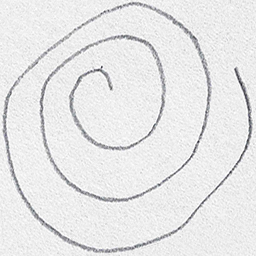

Correct sample: PD_Dataset/spiral/testing/healthy/V01HE01.png actual 0 pred 0 prob 0.22105365982232045


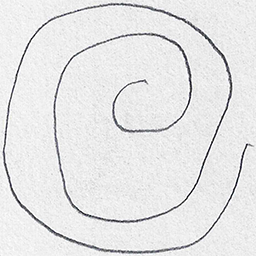

Correct sample: PD_Dataset/spiral/testing/parkinson/V08PE01.png actual 1 pred 1 prob 0.6874993238288375


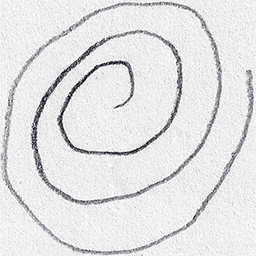

Correct sample: PD_Dataset/spiral/testing/parkinson/V06PE01.png actual 1 pred 1 prob 0.6874993238288375


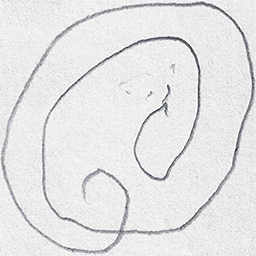


*** wave best: wave_SVM_emb ***
Correct sample: PD_Dataset/wave/testing/healthy/V08HO01.png actual 0 pred 0 prob 0.4551429770397572


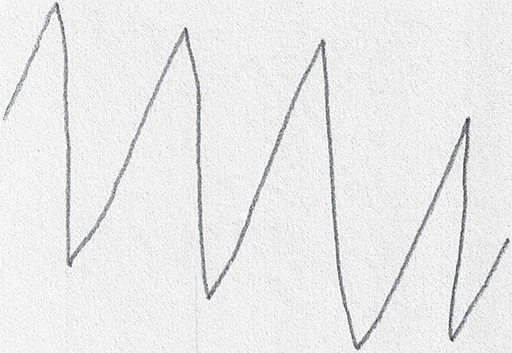

Correct sample: PD_Dataset/wave/testing/healthy/V06HO01.png actual 0 pred 0 prob 0.1718615556500191


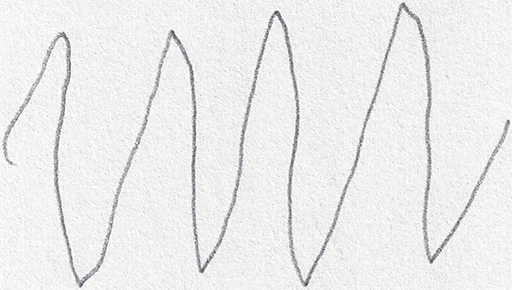

Correct sample: PD_Dataset/wave/testing/parkinson/V06PO01.png actual 1 pred 1 prob 0.8585501955907945


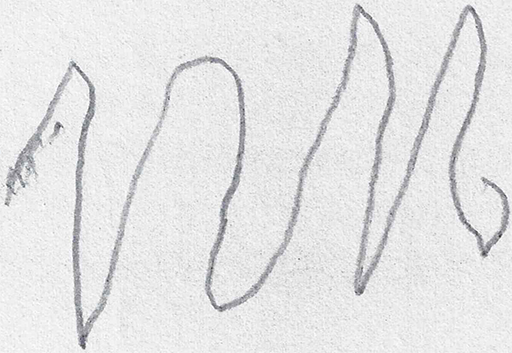

Correct sample: PD_Dataset/wave/testing/parkinson/V02PO01.png actual 1 pred 1 prob 0.9588675490191269


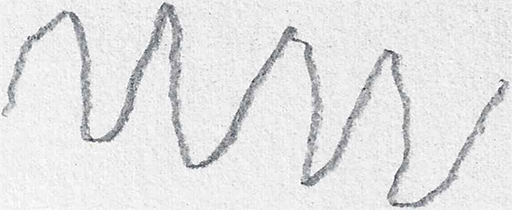

In [50]:
# ----------------- IMAGE pipeline -----------------
image_results = []
if os.path.exists(IMAGE_ROOT):
    print('\n=== IMAGE PIPELINE ===')
    for mod in ['spiral','wave']:
        print(f'\n--- Modality: {mod} ---')
        train_dir = os.path.join(IMAGE_ROOT, mod, 'training')
        test_dir = os.path.join(IMAGE_ROOT, mod, 'testing')
        if not (os.path.exists(train_dir) and os.path.exists(test_dir)):
            print(f'Expected {train_dir} and {test_dir}. Skipping {mod}.')
            continue

        train_ds = image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int', shuffle=True, seed=SEED)
        test_ds = image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=1, label_mode='int', shuffle=False)
        print('Classes:', train_ds.class_names)

        # Build base MobileNetV2
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=IMG_SIZE+(3,))
        base.trainable = False
        inputs = layers.Input(shape=IMG_SIZE+(3,))
        x = layers.Rescaling(1./127.5, offset=-1)(inputs)
        x = base(x, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        outputs = layers.Dense(1, activation='sigmoid')(x)
        cnn = models.Model(inputs, outputs)
        cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

        # Train CNN (transfer)
        cnn.fit(train_ds, validation_data=test_ds, epochs=EPOCHS_CNN, verbose=1)
        cnn.save(f'{MODEL_DIR}/{mod}_cnn.keras')

        # Evaluate CNN on test
        y_true, y_pred, y_prob = [], [], []
        for batch, labels in test_ds:
            probs = cnn.predict(batch, verbose=0)[:,0]
            preds = (probs >= 0.5).astype(int)
            y_prob.append(float(probs[0])); y_pred.append(int(preds[0])); y_true.append(int(labels.numpy()[0]))
        rec_cnn = metrics_summary(y_true, y_pred, np.array(y_prob))
        rec_cnn['model'] = f'{mod}_CNN'
        image_results.append(rec_cnn)
        # save plots
        save_confusion_matrix(y_true, y_pred, f'{mod} CNN (test)', f'{mod}_cnn')
        save_roc_curve(y_true, np.array(y_prob), f'{mod} CNN (test)', f'{mod}_cnn')
        save_pr_curve(y_true, np.array(y_prob), f'{mod} CNN (test)', f'{mod}_cnn')

        # Extract embeddings (frozen base)
        emb_model = models.Model(inputs=base.input, outputs=layers.GlobalAveragePooling2D()(base.output))

        def ds_to_embs(ds):
            embs=[]; lbls=[]
            for batch, labels in ds:
                batch_p = (batch/127.5) - 1.0
                emb = emb_model.predict(batch_p, verbose=0)
                for i in range(emb.shape[0]):
                    embs.append(emb[i])
                for l in labels.numpy():
                    lbls.append(int(l))
            return np.vstack(embs), np.array(lbls)

        # get embeddings from training and test (use batch_size=1 iterators to exhaust)
        train_ds_noshuffle = image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size=1, label_mode='int', shuffle=False)
        train_embs, train_labels = ds_to_embs(train_ds_noshuffle)
        test_embs, test_labels = ds_to_embs(test_ds)

        # scale embeddings
        emb_scaler = StandardScaler().fit(train_embs)
        train_embs_s = emb_scaler.transform(train_embs)
        test_embs_s = emb_scaler.transform(test_embs)
        joblib.dump(emb_scaler, f'{MODEL_DIR}/{mod}_emb_scaler.joblib')

        # SVM on embeddings
        svc = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=SEED)
        svc_cv = GridSearchCV(svc, {'C':[1,5]}, scoring='f1', cv=3, n_jobs=-1)
        svc_cv.fit(train_embs_s, train_labels)
        svc_best = svc_cv.best_estimator_
        svc_cal = CalibratedClassifierCV(svc_best, cv='prefit'); svc_cal.fit(train_embs_s, train_labels)
        y_pred_svc = svc_cal.predict(test_embs_s)
        y_prob_svc = svc_cal.predict_proba(test_embs_s)[:,1]
        rec_svc = metrics_summary(test_labels, y_pred_svc, y_prob_svc)
        rec_svc['model'] = f'{mod}_SVM_emb'
        image_results.append(rec_svc)
        save_confusion_matrix(test_labels, y_pred_svc, f'{mod} SVM-on-emb (test)', f'{mod}_svc_emb')
        save_roc_curve(test_labels, y_prob_svc, f'{mod} SVM-on-emb (test)', f'{mod}_svc_emb')
        save_pr_curve(test_labels, y_prob_svc, f'{mod} SVM-on-emb (test)', f'{mod}_svc_emb')
        joblib.dump(svc_cal, f'{MODEL_DIR}/{mod}_svc_emb.joblib')

        # kNN on embeddings
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(train_embs_s, train_labels)
        knn_cal = CalibratedClassifierCV(knn, cv='prefit'); knn_cal.fit(train_embs_s, train_labels)
        y_pred_knn = knn_cal.predict(test_embs_s)
        y_prob_knn = knn_cal.predict_proba(test_embs_s)[:,1]
        rec_knn = metrics_summary(test_labels, y_pred_knn, y_prob_knn)
        rec_knn['model'] = f'{mod}_kNN_emb'
        image_results.append(rec_knn)
        save_confusion_matrix(test_labels, y_pred_knn, f'{mod} kNN-on-emb (test)', f'{mod}_knn_emb')
        save_roc_curve(test_labels, y_prob_knn, f'{mod} kNN-on-emb (test)', f'{mod}_knn_emb')
        save_pr_curve(test_labels, y_prob_knn, f'{mod} kNN-on-emb (test)', f'{mod}_knn_emb')
        joblib.dump(knn_cal, f'{MODEL_DIR}/{mod}_knn_emb.joblib')

    image_df = pd.DataFrame(image_results).sort_values('f1', ascending=False).reset_index(drop=True)
    image_df.to_csv(f'{OUTPUT_DIR}/image_test_metrics.csv', index=False)
    print('\nImage results table:')
    display_table(image_df, title='Image test metrics (sorted by F1)')

    # For each modality, declare best model and show confusion + ROC for that best
    for mod in ['spiral','wave']:
        sub = image_df[image_df['model'].str.startswith(mod)]
        if sub.empty: continue
        best_row = sub.sort_values('f1', ascending=False).iloc[0]
        best_model_name = best_row['model']
        print(f'\nBest image model for {mod}: {best_model_name} (F1={best_row["f1"]:.4f})')
        # Show best confusion + ROC PNG paths (they were saved earlier)
        print(f'Confusion & ROC saved under {OUTPUT_DIR}/ with prefix {mod}_*')

    # Random-sample testing for best image models: try to find correct images and display them
    print('\nRunning random-sample checks for best image models (attempts to find correctly-predicted samples)...')
    for mod in ['spiral','wave']:
        sub = image_df[image_df['model'].str.startswith(mod)]
        if sub.empty: continue
        best_model_name = sub.sort_values('f1', ascending=False).iloc[0]['model']
        print(f'\n*** {mod} best: {best_model_name} ***')
        # If CNN:
        if best_model_name.endswith('_CNN'):
            model_path = f'{MODEL_DIR}/{mod}_cnn.keras'
            if not os.path.exists(model_path):
                print('CNN model not found:', model_path); continue
            model = tf.keras.models.load_model(model_path)
            # build list of test file paths and labels
            files=[]; labels=[]
            for cls in sorted(os.listdir(os.path.join(IMAGE_ROOT, mod, 'testing'))):
                cls_dir = os.path.join(IMAGE_ROOT, mod, 'testing', cls)
                if not os.path.isdir(cls_dir): continue
                for fn in os.listdir(cls_dir):
                    files.append(os.path.join(cls_dir, fn))
                    labels.append(0 if cls.lower().startswith('hea') else 1)
            attempts=400; need_per_class=2
            found={'0':[],'1':[]}
            for _ in range(attempts):
                i = random.randrange(0,len(files))
                p = files[i]; actual = labels[i]
                img = tf.keras.utils.load_img(p, target_size=IMG_SIZE)
                arr = tf.keras.utils.img_to_array(img)[None,...]; arr = (arr/127.5)-1.0
                prob = float(model.predict(arr, verbose=0)[0,0])
                pred = 1 if prob>=0.5 else 0
                if pred==actual and len(found[str(actual)])<need_per_class:
                    found[str(actual)].append((p, actual, pred, prob))
                if len(found['0'])>=need_per_class and len(found['1'])>=need_per_class:
                    break
            for lab in ['0','1']:
                if found[lab]:
                    for p, actual, pred, prob in found[lab]:
                        print('Correct sample:', p, 'actual', actual, 'pred', pred, 'prob', prob)
                        display(IPImage(p, width=256))
                else:
                    print(f'No correct samples found for class {lab} for {mod} CNN within attempts.')
        else:
            # SVM/kNN on embeddings
            scaler_file = f'{MODEL_DIR}/{mod}_emb_scaler.joblib'
            if not os.path.exists(scaler_file):
                print('No emb scaler for', mod); continue
            emb_scaler = joblib.load(scaler_file)
            base = MobileNetV2(weights='imagenet', include_top=False, input_shape=IMG_SIZE+(3,))
            emb_model = models.Model(inputs=base.input, outputs=layers.GlobalAveragePooling2D()(base.output))
            if '_SVM_emb' in best_model_name:
                clf = joblib.load(f'{MODEL_DIR}/{mod}_svc_emb.joblib')
            elif '_kNN_emb' in best_model_name:
                clf = joblib.load(f'{MODEL_DIR}/{mod}_knn_emb.joblib')
            else:
                print('Unknown best model type for', best_model_name); continue
            files=[]; labels=[]
            for cls in sorted(os.listdir(os.path.join(IMAGE_ROOT, mod, 'testing'))):
                cls_dir = os.path.join(IMAGE_ROOT, mod, 'testing', cls)
                if not os.path.isdir(cls_dir): continue
                for fn in os.listdir(cls_dir):
                    files.append(os.path.join(cls_dir, fn))
                    labels.append(0 if cls.lower().startswith('hea') else 1)
            attempts=400; need_per_class=2
            found={'0':[],'1':[]}
            for _ in range(attempts):
                i = random.randrange(0,len(files))
                p = files[i]; actual = labels[i]
                img = tf.keras.utils.load_img(p, target_size=IMG_SIZE)
                arr = tf.keras.utils.img_to_array(img)[None,...]; arr = (arr/127.5)-1.0
                emb = emb_model.predict(arr, verbose=0)
                emb_s = emb_scaler.transform(emb)
                prob = float(clf.predict_proba(emb_s)[0,1]) if hasattr(clf,'predict_proba') else None
                pred = int(clf.predict(emb_s)[0])
                if pred==actual and len(found[str(actual)])<need_per_class:
                    found[str(actual)].append((p, actual, pred, prob))
                if len(found['0'])>=need_per_class and len(found['1'])>=need_per_class:
                    break
            for lab in ['0','1']:
                if found[lab]:
                    for p, actual, pred, prob in found[lab]:
                        print('Correct sample:', p, 'actual', actual, 'pred', pred, 'prob', prob)
                        display(IPImage(p, width=256))
                else:
                    print(f'No correct samples found for class {lab} for {mod} {best_model_name} within attempts.')

else:
    print('\nSkipping image pipeline because image root not found.')

In [49]:
# ----------------- AGGREGATE SUMMARY -----------------
print('\n=== AGGREGATE SUMMARY ===')
frames=[]
if 'voice_results_df' in locals() and voice_results_df is not None:
    dfv = voice_results_df.copy()
    dfv['modality']='voice'
    frames.append(dfv[['modality','model','accuracy','precision','recall','f1','mcc','auc']])
if 'image_df' in locals() and 'image_df' in globals():
    dfi = image_df.copy()
    dfi['modality']='image'
    frames.append(dfi[['modality','model','accuracy','precision','recall','f1','mcc','auc']])
if frames:
    agg = pd.concat(frames, ignore_index=True).sort_values(['modality','f1'], ascending=[True,False]).reset_index(drop=True)
    display_table(agg, title='Aggregate results (voice + image)')
    agg.to_csv(f'{OUTPUT_DIR}/aggregate_results.csv', index=False)
else:
    print('No results to summarize.')

print('\nAll artifacts (models + plots + CSVs) saved in ./models and ./outputs')
print('If image pipeline did not run, make sure PD_Dataset.zip is uploaded and contains spiral/ and wave/ with training/ and testing/ subfolders.')


=== AGGREGATE SUMMARY ===
Aggregate results (voice + image)
| modality   | model          |   accuracy |   precision |   recall |     f1 |    mcc |    auc |
|:-----------|:---------------|-----------:|------------:|---------:|-------:|-------:|-------:|
| image      | wave_SVM_emb   |     0.9333 |      0.9333 |   0.9333 | 0.9333 | 0.8667 | 0.9467 |
| image      | spiral_kNN_emb |     0.8333 |      0.8571 |   0.8000 | 0.8276 | 0.6682 | 0.8956 |
| image      | wave_CNN       |     0.8333 |      0.8571 |   0.8000 | 0.8276 | 0.6682 | 0.9333 |
| image      | spiral_SVM_emb |     0.8000 |      0.7368 |   0.9333 | 0.8235 | 0.6225 | 0.8800 |
| image      | wave_kNN_emb   |     0.8000 |      0.8462 |   0.7333 | 0.7857 | 0.6054 | 0.8600 |
| image      | spiral_CNN     |     0.7667 |      0.7857 |   0.7333 | 0.7586 | 0.5345 | 0.8756 |
| voice      | MLP            |     0.9487 |      0.9655 |   0.9655 | 0.9655 | 0.8655 | 0.9862 |
| voice      | kNN            |     0.9231 |      0.9333 |   0.965

In [48]:
# First 10 predictions
for i in range(10):
    if prediction[i] == 1:
        print(f"Sample {i}: 🩺 Parkinson's")
    else:
        print(f"Sample {i}: ✅ Healthy")

    print("Actual label:", y_test.iloc[i])

Sample 0: ✅ Healthy
Actual label: 0
Sample 1: 🩺 Parkinson's
Actual label: 1
Sample 2: 🩺 Parkinson's
Actual label: 1
Sample 3: 🩺 Parkinson's
Actual label: 1
Sample 4: ✅ Healthy
Actual label: 0
Sample 5: 🩺 Parkinson's
Actual label: 1
Sample 6: 🩺 Parkinson's
Actual label: 1
Sample 7: 🩺 Parkinson's
Actual label: 1
Sample 8: ✅ Healthy
Actual label: 0
Sample 9: 🩺 Parkinson's
Actual label: 1
